In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from pandas import DataFrame, Series
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [ ]:
path = '/content/drive/MyDrive/自主学習/kaggle_data/house-prices-advanced-regression-techniques/'

df = pd.read_csv(path + 'train.csv')
df_test = pd.read_csv(path + 'test.csv')

## EDA


In [ ]:
print('訓練データのデータ数は{}、変数は{}種類です。'.format(df.shape[0], df.shape[1]))
print('テストデータのデータ数は{}、変数は{}種類です'.format(df_test.shape[0], df.shape[1]))

訓練データのデータ数は1460、変数は81種類です。
テストデータのデータ数は1459、変数は81種類です


In [ ]:
with pd.option_context('display.max_columns', None):
  display(df.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

カラムの分類
🏷️ 識別子・目的変数

Id: 物件ID(特徴量としては使わない、最後の提出で必要)
SalePrice: 目的変数(これを予測する)

🏘️ 立地・敷地

MSSubClass: 建物のタイプ(数値だけどカテゴリ変数!要注意)
MSZoning: 用途地域(住宅地、商業地など)
LotFrontage: 道路に面している長さ
LotArea: 敷地面積
Street, Alley: 道路・路地の種類
LotShape, LandContour, LandSlope: 土地の形状・傾斜
LotConfig: 区画の配置
Neighborhood: 地区名(これ超重要、価格に強く効く)
Condition1, Condition2: 周辺環境(線路近い、幹線道路近い、など)

🏠 建物の基本情報

BldgType: 建物タイプ(一戸建て、二世帯、など)
HouseStyle: 建物の様式(1階建て、2階建て、など)
OverallQual: 全体的な品質(1-10の順序尺度、超重要)
OverallCond: 全体的な状態(1-10、これも重要)
YearBuilt: 建築年
YearRemodAdd: リフォーム年

🏛️ 外装・屋根

RoofStyle, RoofMatl: 屋根のスタイル・素材
Exterior1st, Exterior2nd: 外装材
MasVnrType, MasVnrArea: 化粧張りの種類・面積
ExterQual, ExterCond: 外装の品質・状態(Ex/Gd/TA/Fa/Po の順序尺度)
Foundation: 基礎の種類

🏚️ 地下室

BsmtQual, BsmtCond: 地下室の品質・状態
BsmtExposure: 地下室の採光
BsmtFinType1, BsmtFinType2: 仕上げの種類
BsmtFinSF1, BsmtFinSF2: 仕上げ済み面積
BsmtUnfSF: 未仕上げ面積
TotalBsmtSF: 地下室の総面積

🔥 空調・電気

Heating, HeatingQC: 暖房の種類・品質
CentralAir: セントラルエアコン(Y/N)
Electrical: 電気系統

📐 床面積(超重要グループ)

1stFlrSF: 1階の床面積
2ndFlrSF: 2階の床面積
LowQualFinSF: 低品質仕上げの面積
GrLivArea: 地上階の床面積(これがSalePriceに最も強く効く特徴量の一つ)

🚿 部屋数

BsmtFullBath, BsmtHalfBath: 地下のバスルーム
FullBath, HalfBath: 地上のバスルーム
BedroomAbvGr: 寝室数(地上)
KitchenAbvGr: キッチン数
KitchenQual: キッチンの品質
TotRmsAbvGrd: 地上の総部屋数
Functional: 機能性の評価

🔥 暖炉

Fireplaces: 暖炉の数
FireplaceQu: 暖炉の品質

🚗 ガレージ

GarageType: ガレージのタイプ
GarageYrBlt: ガレージ建築年
GarageFinish: ガレージの仕上げ
GarageCars: 駐車可能台数
GarageArea: ガレージ面積
GarageQual, GarageCond: ガレージの品質・状態
PavedDrive: 舗装されたドライブウェイか

🌳 その他の外構

WoodDeckSF: ウッドデッキの面積
OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch: 各種ポーチの面積
PoolArea, PoolQC: プール面積・品質
Fence: フェンスの種類
MiscFeature, MiscVal: その他の設備(納屋、テニスコートなど)・その価値

💰 販売情報

MoSold, YrSold: 販売月・年
SaleType: 販売の種類
SaleCondition: 販売条件(通常、競売、家族間取引、など)





In [ ]:
df = df.drop('Id', axis=1)
df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '欠損数': missing,
    '欠損率(%)': missing_pct
})

missing_test = df_test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
missing_pct_test = (missing_test / len(df) * 100).round(2)

missing_df_test = pd.DataFrame({
    '欠損数': missing_test,
    '欠損率(%)': missing_pct_test
})
print("=== train ===")
print(missing_df)

print('\n== test ===')
print(missing_df_test)

=== train ===
               欠損数  欠損率(%)
PoolQC        1453   99.52
MiscFeature   1406   96.30
Alley         1369   93.77
Fence         1179   80.75
MasVnrType     872   59.73
FireplaceQu    690   47.26
LotFrontage    259   17.74
GarageType      81    5.55
GarageYrBlt     81    5.55
GarageFinish    81    5.55
GarageQual      81    5.55
GarageCond      81    5.55
BsmtExposure    38    2.60
BsmtFinType2    38    2.60
BsmtQual        37    2.53
BsmtCond        37    2.53
BsmtFinType1    37    2.53
MasVnrArea       8    0.55
Electrical       1    0.07

== test ===
               欠損数  欠損率(%)
PoolQC        1456   99.73
MiscFeature   1408   96.44
Alley         1352   92.60
Fence         1169   80.07
MasVnrType     894   61.23
FireplaceQu    730   50.00
LotFrontage    227   15.55
GarageQual      78    5.34
GarageCond      78    5.34
GarageYrBlt     78    5.34
GarageFinish    78    5.34
GarageType      76    5.21
BsmtCond        45    3.08
BsmtQual        44    3.01
BsmtExposure    44    3.01
B

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


<Axes: xlabel='SalePrice', ylabel='Count'>

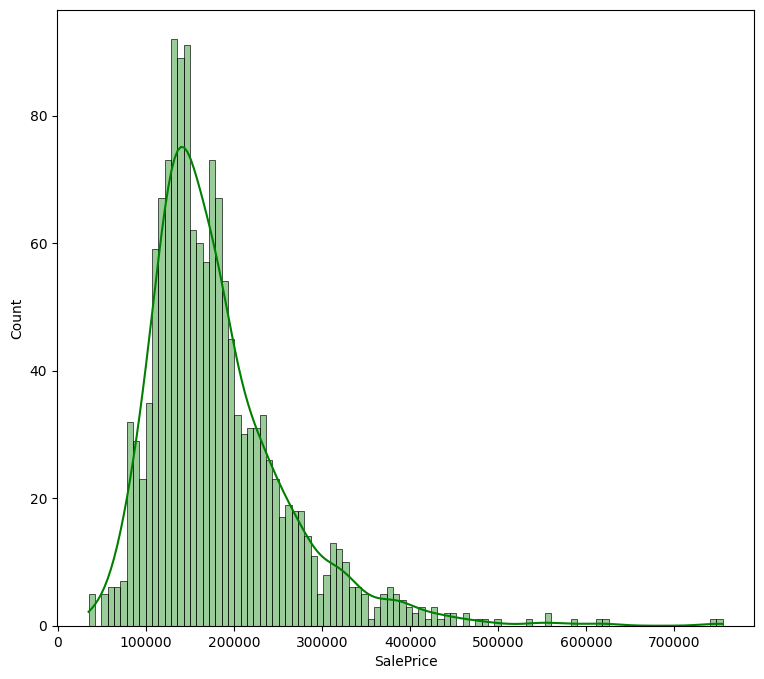

In [ ]:
print(df['SalePrice'].describe())
plt.figure(figsize=(9, 8))
sns.histplot(df['SalePrice'], color='g', bins=100, kde=True, alpha=0.4)

In [ ]:
df.dtypes.unique()

array([dtype('int64'), dtype('O'), dtype('float64')], dtype=object)

In [ ]:
df_num = df.select_dtypes(include  = ['float64', 'int64'])
df_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

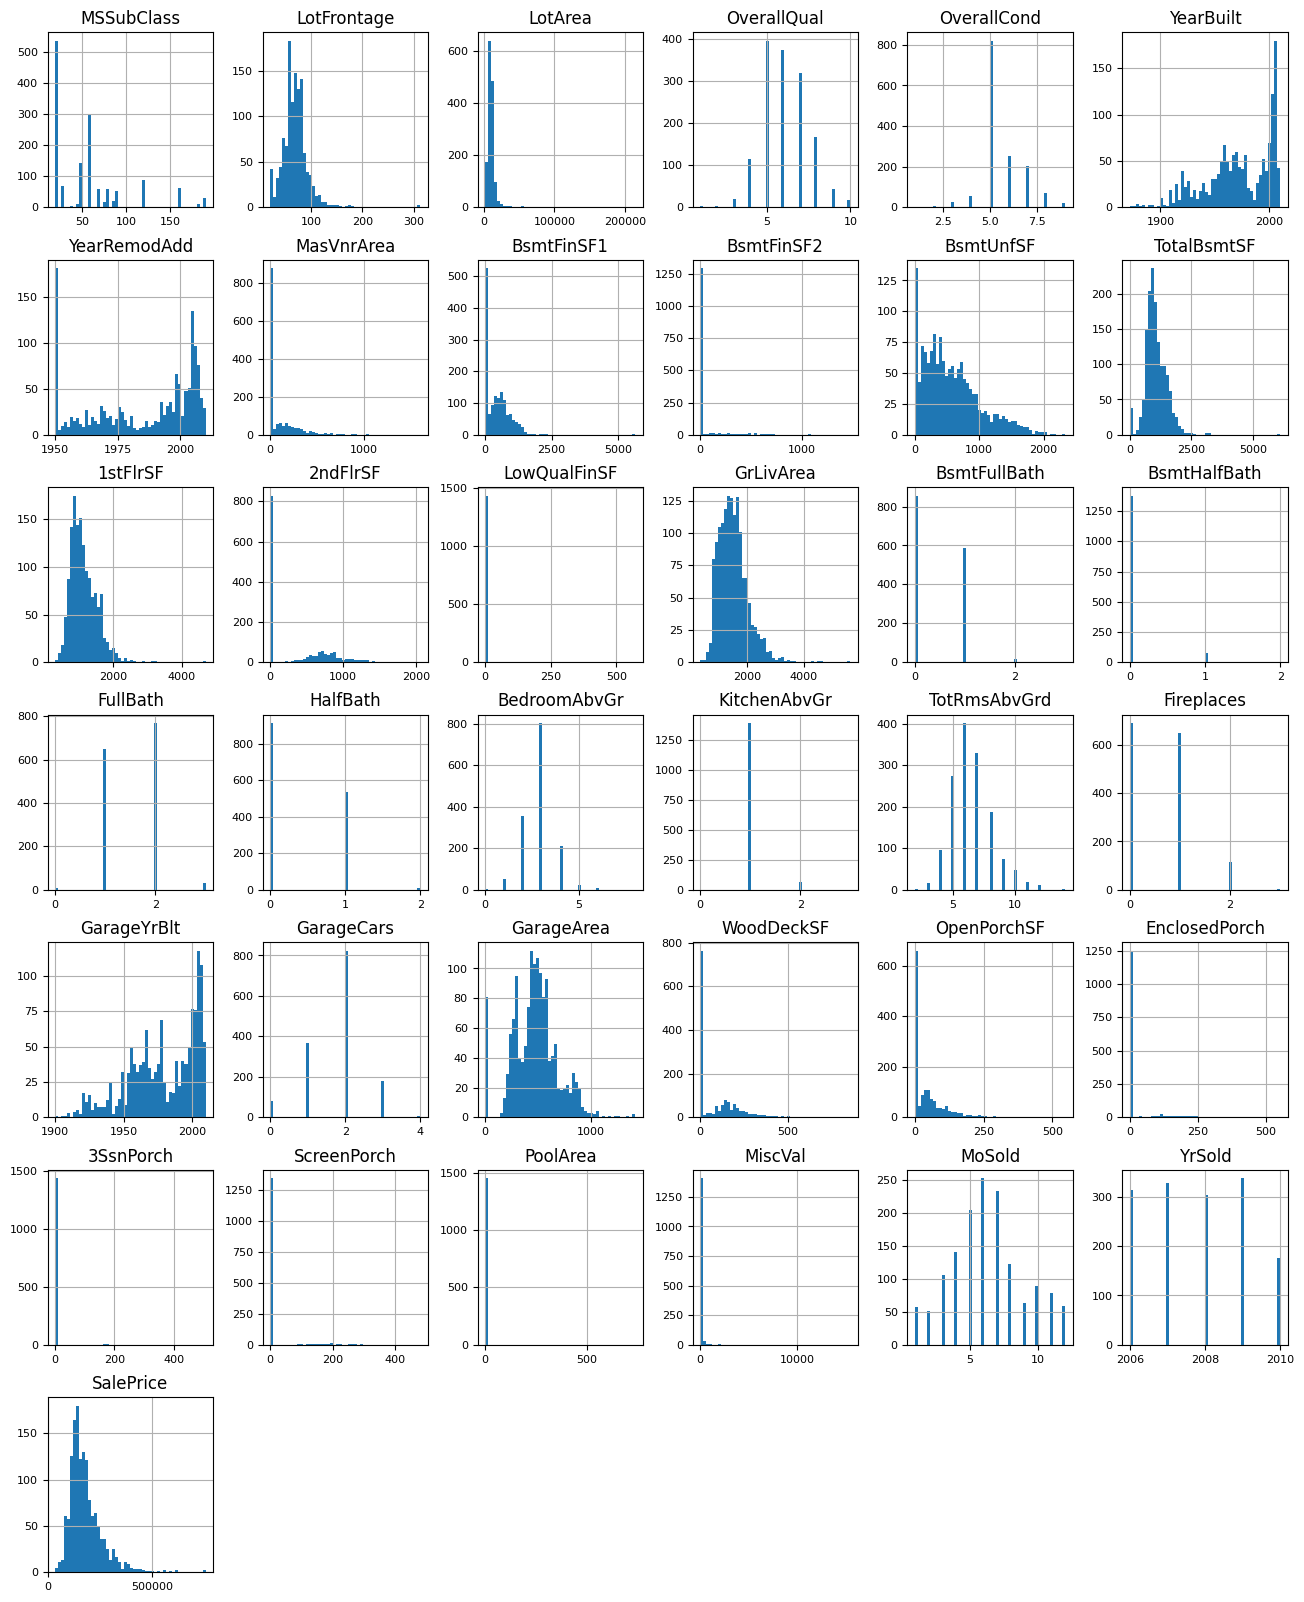

In [ ]:
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

In [ ]:
df.dtypes.value_counts()

,count
object,43
int64,34
float64,3


In [ ]:
df.select_dtypes(include='int64').columns

Index(['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [ ]:
df['MSSubClass'] = df['MSSubClass'].astype(str)

In [ ]:
print(df.groupby('MoSold')['SalePrice'].mean())
print(df[['MoSold', 'SalePrice']].corr())

MoSold
1     183256.258621
2     177882.000000
3     183253.924528
4     171503.262411
5     172307.269608
6     177395.735178
7     186331.192308
8     184651.827869
9     195683.206349
10    179563.977528
11    192210.911392
12    186518.966102
Name: SalePrice, dtype: float64
             MoSold  SalePrice
MoSold     1.000000   0.046432
SalePrice  0.046432   1.000000


In [ ]:
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


欠損値の処理と前処理

In [ ]:
all_y = df['SalePrice']

all_df = pd.concat([df.drop(['SalePrice'], axis=1), df_test], axis=0).reset_index(drop=True)
print(f'全データ数：{all_df.shape}')

全データ数：(2919, 80)


In [ ]:
none_cols = ['PoolQC', 'MiscFeature','Alley', 'Fence', 'MasVnrType', 'FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtQual', 'BsmtCond']

for col in none_cols:
  all_df[col] = all_df[col].fillna('None')

zero_cols = ['GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF','BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
  all_df[col] = all_df[col].fillna(0)


In [ ]:
all_df['LotFrontage'] = all_df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd','SaleType', 'Functional', 'Utilities']
for col in mode_cols:
  all_df[col] = all_df[col].fillna(all_df[col].mode()[0])

all_df['GarageYrBlt'] = all_df['GarageYrBlt'].fillna(all_df['YearBuilt'])

In [ ]:
y_train_log = np.log1p(all_y)

特徴量エンジニアリング

In [ ]:
all_df['MSSubClass'] = all_df['MSSubClass'].astype(str)
all_df['MoSold'] = all_df['MoSold'].astype(str)

In [ ]:
all_df['TotalSF'] = all_df['1stFlrSF'] + all_df['2ndFlrSF'] + all_df['TotalBsmtSF']

エンコーディング

In [ ]:
all_df_encoded = pd.get_dummies(all_df)

x_train = all_df_encoded.iloc[:len(df)]
x_test = all_df_encoded.iloc[len(df):]

print(f'エンコーディング後の訓練データサイズ: {x_train.shape}')
print(f'エンコーディング後の訓練データサイズ: {x_test.shape}')

エンコーディング後の訓練データサイズ: (1460, 330)
エンコーディング後の訓練データサイズ: (1459, 330)


モデルの構築

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error


x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train_log, test_size=0.2, random_state=42)

train_data = lgb.Dataset(x_tr, label=y_tr)
val_data = lgb.Dataset(x_val, label=y_val)

params = {
    'objective':'regression',
    'metric':'rmse',
    'learning_rate': 0.05,
    'num_leaves':31,
    'seed':42,
    'verbose':-1,

}

model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, val_data],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]

)

val_pred = model.predict(x_val)
rmse_score = root_mean_squared_error(y_val, val_pred)
print(f'バリデーションデータのRMSLEスコア:{rmse_score:4f}')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[308]	training's rmse: 0.0295303	valid_1's rmse: 0.138515
バリデーションデータのRMSLEスコア:0.138515


In [ ]:
test_pred_log = model.predict(x_test)

test_pred = np.expm1(test_pred_log)

submission = pd.DataFrame({
    'Id' : df_test['Id'],
    'SalePrice': test_pred
})

submission.to_csv('submission.csv', index=False)
print('提出用ファイル "submission.csv"が完成しました！')

提出用ファイル "submission.csv"が完成しました！
